In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict


# Cấu hình giao diện đồ thị
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# AOD data EDA

In [2]:
dir = r"/home/slow_data/Air_Quality/AOD/full_aod/"

In [3]:
base_dir = Path(dir)

## Data Stat

In [5]:
data_structure = []

for yyyymm_dir in sorted(base_dir.glob('[0-9][0-9][0-9][0-9][0-9][0-9]')):
    year_month = yyyymm_dir.name
    
    for dd_dir in sorted(yyyymm_dir.glob('[0-9][0-9]')):
        day = dd_dir.name
        
        for hh_dir in sorted(dd_dir.glob('[0-9][0-9]')):
            hour = hh_dir.name
            
            # Count .tif files
            tif_files = list(hh_dir.glob('*.tif'))
            n_files = len(tif_files)
            
            data_structure.append({
                'year_month': year_month,
                'day': day,
                'hour': hour,
                'datetime': f"{year_month}{day}{hour}",
                'n_files': n_files,
                'expected': 6,
                'status': 'complete' if n_files == 6 else 'incomplete',
                'missing': 6 - n_files if n_files < 6 else 0,
                'path': str(hh_dir)
            })

df = pd.DataFrame(data_structure)
print(f"Total hours scanned: {len(df)}")
df.head(10)

Total hours scanned: 27992


,year_month,day,hour,datetime,n_files,expected,status,missing,path
0,202209,27,00,2022092700,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
1,202209,27,01,2022092701,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
2,202209,27,02,2022092702,5,6,incomplete,1,/home/slow_data/Air_Quality/AOD/full_aod/20220...
3,202209,27,03,2022092703,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
4,202209,27,04,2022092704,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
5,202209,27,05,2022092705,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
6,202209,27,06,2022092706,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
7,202209,27,07,2022092707,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
8,202209,27,08,2022092708,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...
9,202209,27,09,2022092709,6,6,complete,0,/home/slow_data/Air_Quality/AOD/full_aod/20220...


In [6]:
print("=== OVERALL STATISTICS ===")
print(f"Total hours in dataset: {len(df)}")
print(f"Total files found: {df['n_files'].sum()}")
print(f"Expected total files: {len(df) * 6}")
print(f"Missing files: {df['missing'].sum()}")
print(f"\nComplete hours (6 files): {(df['status'] == 'complete').sum()}")
print(f"Incomplete hours: {(df['status'] == 'incomplete').sum()}")
print(f"Completeness rate: {(df['status'] == 'complete').sum() / len(df) * 100:.2f}%")

=== OVERALL STATISTICS ===
Total hours in dataset: 27992
Total files found: 164420
Expected total files: 167952
Missing files: 3532

Complete hours (6 files): 25097
Incomplete hours: 2895
Completeness rate: 89.66%


In [7]:
print("\n=== FILES PER HOUR DISTRIBUTION ===")
print(df['n_files'].value_counts().sort_index())
print("\nPercentage:")
percent=df['n_files'].value_counts(normalize=True).sort_index() * 100
print(percent)


=== FILES PER HOUR DISTRIBUTION ===
n_files
0       87
1       18
2       21
3       18
4       31
5     2720
6    25097
Name: count, dtype: int64

Percentage:
n_files
0     0.310803
1     0.064304
2     0.075021
3     0.064304
4     0.110746
5     9.717062
6    89.657759
Name: proportion, dtype: float64


In [8]:
monthly_stats = df.groupby('year_month').agg({
    'n_files': ['count', 'sum', 'mean'],
    'missing': 'sum',
    'status': lambda x: (x == 'complete').sum()
}).round(2)

monthly_stats.columns = ['n_hours', 'total_files', 'avg_files_per_hour', 'missing_files', 'complete_hours']
monthly_stats['completeness_pct'] = (monthly_stats['complete_hours'] / monthly_stats['n_hours'] * 100).round(2)
print("\n=== MONTHLY STATISTICS ===")
print(monthly_stats)


=== MONTHLY STATISTICS ===
            n_hours  total_files  avg_files_per_hour  missing_files  \
year_month                                                            
202209           96          563                5.86             13   
202210          744         4373                5.88             91   
202211          720         4237                5.88             83   
202212          744         4374                5.88             90   
202301          744         4385                5.89             79   
202302          672         3953                5.88             79   
202303          744         4387                5.90             77   
202304          720         4252                5.91             68   
202305          744         4393                5.90             71   
202306          720         4251                5.90             69   
202307          744         4392                5.90             72   
202308          744         4387                5

In [9]:
selected_month = df['year_month'].iloc[0]  # Change as needed
print(f"\n=== DAILY STATISTICS FOR {selected_month} ===")

daily_stats = df[df['year_month'] == selected_month].groupby('day').agg({
    'n_files': ['count', 'sum', 'mean'],
    'missing': 'sum',
    'status': lambda x: (x == 'complete').sum()
}).round(2)

daily_stats.columns = ['n_hours', 'total_files', 'avg_files', 'missing', 'complete_hours']
print(daily_stats)


=== DAILY STATISTICS FOR 202209 ===
     n_hours  total_files  avg_files  missing  complete_hours
day                                                          
27        24          141       5.88        3              21
28        24          141       5.88        3              21
29        24          140       5.83        4              20
30        24          141       5.88        3              21


In [10]:
incomplete_df = df[df['status'] == 'incomplete'].copy()
print(f"\n=== INCOMPLETE HOURS ({len(incomplete_df)} total) ===")
print(incomplete_df[['datetime', 'n_files', 'missing', 'path']].head(20))


=== INCOMPLETE HOURS (2895 total) ===
       datetime  n_files  missing  \
2    2022092702        5        1   
14   2022092714        5        1   
18   2022092718        5        1   
26   2022092802        5        1   
28   2022092804        5        1   
38   2022092814        5        1   
50   2022092902        5        1   
52   2022092904        5        1   
62   2022092914        5        1   
70   2022092922        5        1   
74   2022093002        5        1   
82   2022093010        5        1   
86   2022093014        5        1   
98   2022100102        5        1   
110  2022100114        5        1   
122  2022100202        5        1   
134  2022100214        5        1   
146  2022100302        5        1   
158  2022100314        5        1   
170  2022100402        5        1   

                                                  path  
2    /home/slow_data/Air_Quality/AOD/full_aod/20220...  
14   /home/slow_data/Air_Quality/AOD/full_aod/20220...  
18   /home/s

In [11]:
zero_files = df[df['n_files'] == 0]
print(f"\n=== HOURS WITH ZERO FILES ({len(zero_files)} total) ===")
if len(zero_files) > 0:
    print(zero_files[['datetime', 'path']].head(20))
else:
    print("No hours with zero files found!")


=== HOURS WITH ZERO FILES (87 total) ===
         datetime                                               path
1906   2022121510  /home/slow_data/Air_Quality/AOD/full_aod/20221...
2789   2023012105  /home/slow_data/Air_Quality/AOD/full_aod/20230...
3369   2023021409  /home/slow_data/Air_Quality/AOD/full_aod/20230...
9478   2023102622  /home/slow_data/Air_Quality/AOD/full_aod/20231...
10431  2023120515  /home/slow_data/Air_Quality/AOD/full_aod/20231...
10500  2023120812  /home/slow_data/Air_Quality/AOD/full_aod/20231...
12434  2024022702  /home/slow_data/Air_Quality/AOD/full_aod/20240...
15293  2024062505  /home/slow_data/Air_Quality/AOD/full_aod/20240...
16523  2024081511  /home/slow_data/Air_Quality/AOD/full_aod/20240...
17200  2024091216  /home/slow_data/Air_Quality/AOD/full_aod/20240...
17546  2024092702  /home/slow_data/Air_Quality/AOD/full_aod/20240...
17615  2024092923  /home/slow_data/Air_Quality/AOD/full_aod/20240...
19192  2024120416  /home/slow_data/Air_Quality/AOD/full_aod/2

/tmp/ipykernel_57713/155163776.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_complete = df.groupby('year_month').apply(lambda x: (x['status'] == 'complete').sum() / len(x) * 100)


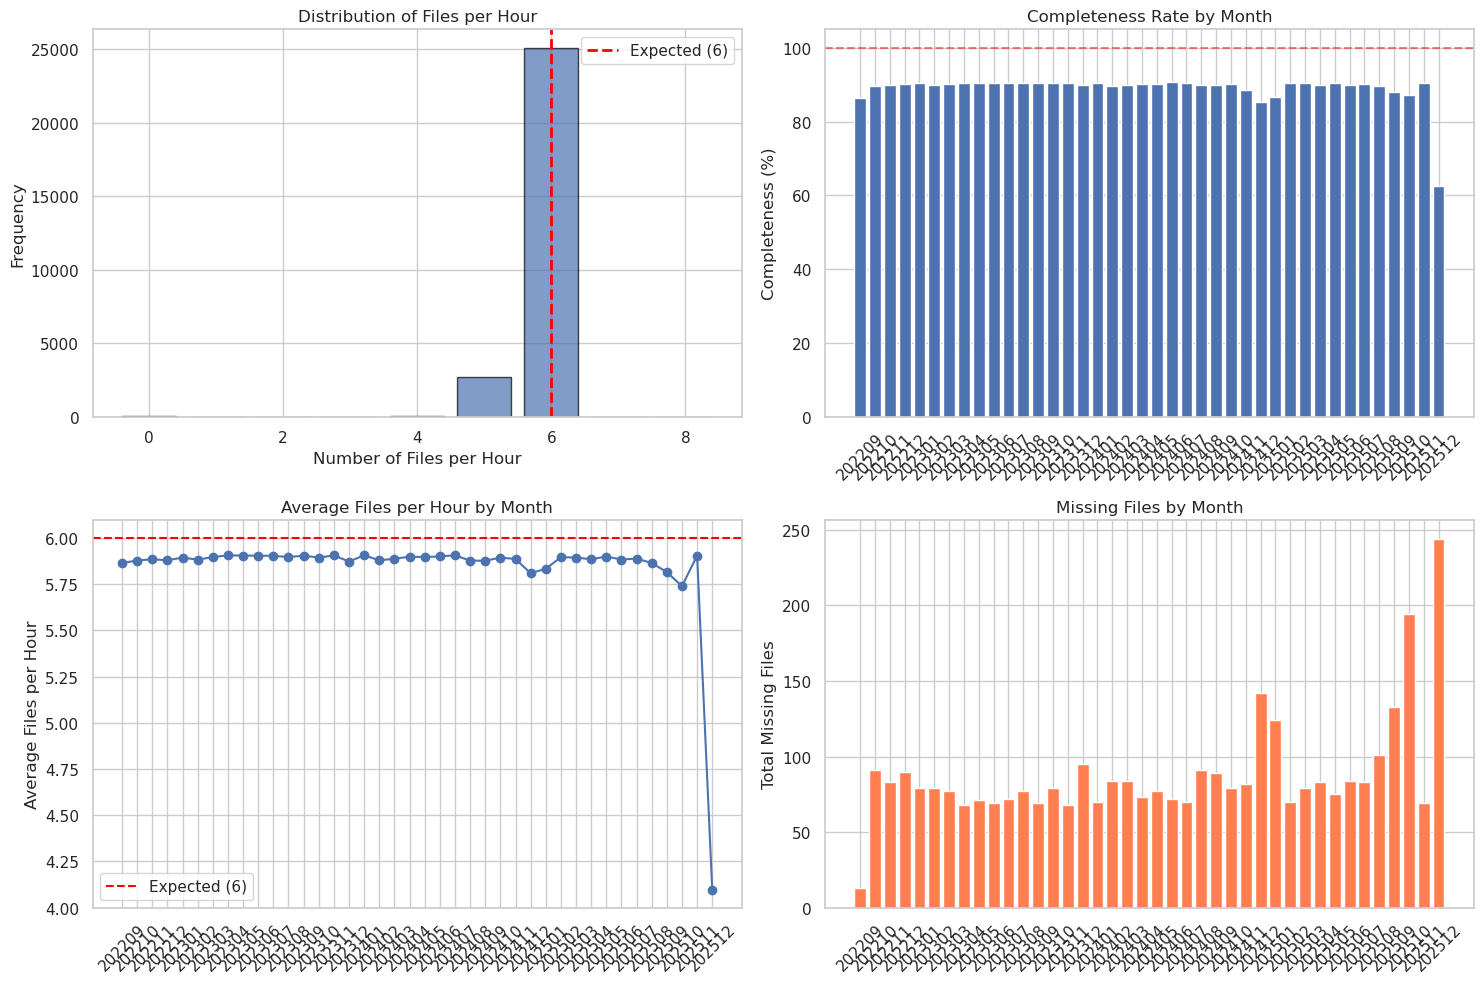

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of files per hour
axes[0, 0].hist(df['n_files'], bins=range(0, 10), edgecolor='black', alpha=0.7, align='left', rwidth=0.8)
axes[0, 0].set_xlabel('Number of Files per Hour')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Files per Hour')
axes[0, 0].axvline(6, color='red', linestyle='--', linewidth=2, label='Expected (6)')
axes[0, 0].legend()

# Completeness by month
monthly_complete = df.groupby('year_month').apply(lambda x: (x['status'] == 'complete').sum() / len(x) * 100)
axes[0, 1].bar(range(len(monthly_complete)), monthly_complete.values)
axes[0, 1].set_xticks(range(len(monthly_complete)))
axes[0, 1].set_xticklabels(monthly_complete.index, rotation=45)
axes[0, 1].set_ylabel('Completeness (%)')
axes[0, 1].set_title('Completeness Rate by Month')
axes[0, 1].axhline(100, color='red', linestyle='--', alpha=0.5)

# Average files per hour by month
monthly_avg = df.groupby('year_month')['n_files'].mean()
axes[1, 0].plot(monthly_avg.values, marker='o')
axes[1, 0].set_xticks(range(len(monthly_avg)))
axes[1, 0].set_xticklabels(monthly_avg.index, rotation=45)
axes[1, 0].set_ylabel('Average Files per Hour')
axes[1, 0].set_title('Average Files per Hour by Month')
axes[1, 0].axhline(6, color='red', linestyle='--', label='Expected (6)')
axes[1, 0].legend()

# Missing files by month
monthly_missing = df.groupby('year_month')['missing'].sum()
axes[1, 1].bar(range(len(monthly_missing)), monthly_missing.values, color='coral')
axes[1, 1].set_xticks(range(len(monthly_missing)))
axes[1, 1].set_xticklabels(monthly_missing.index, rotation=45)
axes[1, 1].set_ylabel('Total Missing Files')
axes[1, 1].set_title('Missing Files by Month')

plt.tight_layout()
plt.show()

In [13]:
df['datetime_obj'] = pd.to_datetime(df['datetime'], format='%Y%m%d%H')
df_sorted = df.sort_values('datetime_obj')

time_diffs = df_sorted['datetime_obj'].diff()
gaps = time_diffs[time_diffs > timedelta(hours=1)]

print(f"\n=== TIME SERIES GAPS (> 1 hour) ===")
print(f"Number of gaps: {len(gaps)}")
if len(gaps) > 0:
    for idx, gap in gaps.items():
        prev_time = df_sorted.loc[idx - 1, 'datetime_obj']
        curr_time = df_sorted.loc[idx, 'datetime_obj']
        print(f"Gap from {prev_time} to {curr_time}: {gap}")


=== TIME SERIES GAPS (> 1 hour) ===
Number of gaps: 0


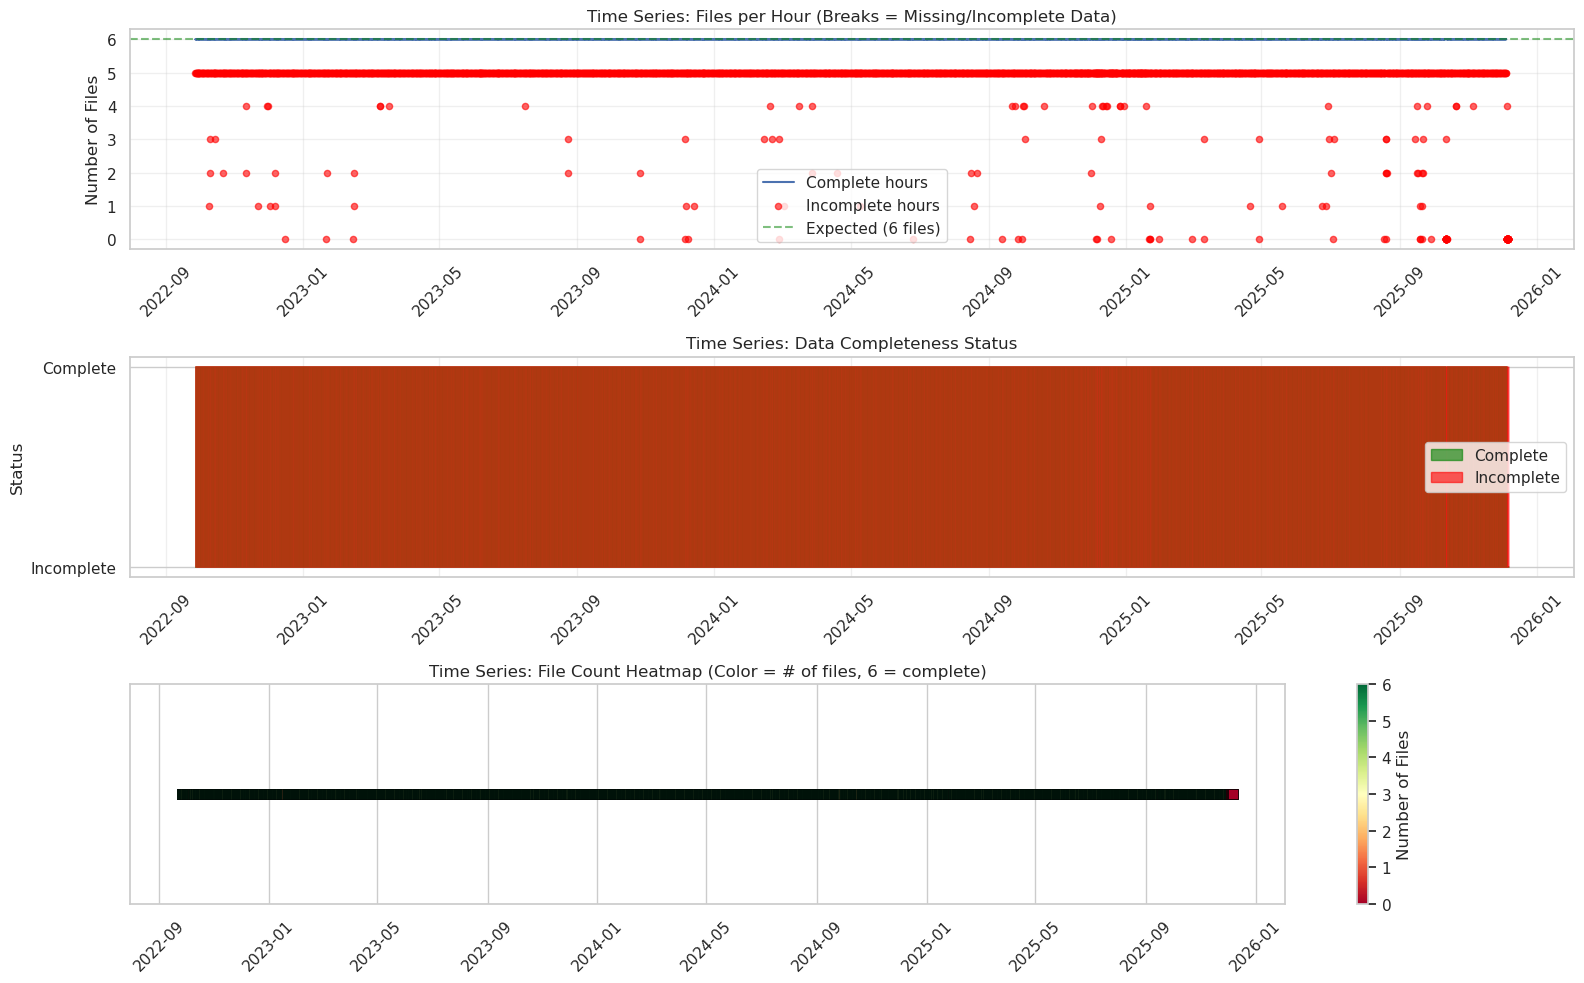

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Prepare data with datetime
df_sorted = df.sort_values('datetime_obj').reset_index(drop=True)

# Method 1: Line plot with breaks (NaN for incomplete)
df_plot1 = df_sorted.copy()
df_plot1.loc[df_plot1['status'] == 'incomplete', 'n_files_plot'] = None
df_plot1.loc[df_plot1['status'] == 'complete', 'n_files_plot'] = df_plot1['n_files']

axes[0].plot(df_plot1['datetime_obj'], df_plot1['n_files_plot'], 
              markersize=3, linewidth=1.5, label='Complete hours')
axes[0].scatter(df_sorted[df_sorted['status'] == 'incomplete']['datetime_obj'],
                df_sorted[df_sorted['status'] == 'incomplete']['n_files'],
                color='red', s=20, alpha=0.6, label='Incomplete hours', zorder=5)
axes[0].axhline(6, color='green', linestyle='--', alpha=0.5, label='Expected (6 files)')
axes[0].set_ylabel('Number of Files')
axes[0].set_title('Time Series: Files per Hour (Breaks = Missing/Incomplete Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Method 2: Completeness indicator (binary: complete or not)
completeness = (df_sorted['status'] == 'complete').astype(int)
axes[1].fill_between(df_sorted['datetime_obj'], 0, completeness, 
                      step='mid', alpha=0.6, color='green', label='Complete')
axes[1].fill_between(df_sorted['datetime_obj'], completeness, 1,
                      step='mid', alpha=0.6, color='red', label='Incomplete')
axes[1].set_ylabel('Status')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Incomplete', 'Complete'])
axes[1].set_title('Time Series: Data Completeness Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Method 3: Heatmap-style timeline showing file count
# Create breaks by setting incomplete to NaN
df_plot3 = df_sorted.copy()
df_plot3.loc[df_plot3['n_files'] < 6, 'n_files_heat'] = None
df_plot3.loc[df_plot3['n_files'] == 6, 'n_files_heat'] = df_plot3['n_files']

# Plot with color intensity
scatter = axes[2].scatter(df_sorted['datetime_obj'], 
                          [1]*len(df_sorted),
                          c=df_sorted['n_files'], 
                          cmap='RdYlGn', 
                          vmin=0, vmax=6,
                          s=50, 
                          marker='s',
                          edgecolors='black',
                          linewidths=0.5)
axes[2].set_ylabel('')
axes[2].set_yticks([])
axes[2].set_title('Time Series: File Count Heatmap (Color = # of files, 6 = complete)')
plt.colorbar(scatter, ax=axes[2], label='Number of Files')
axes[2].set_ylim(0.5, 1.5)

# Format x-axis for all plots
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

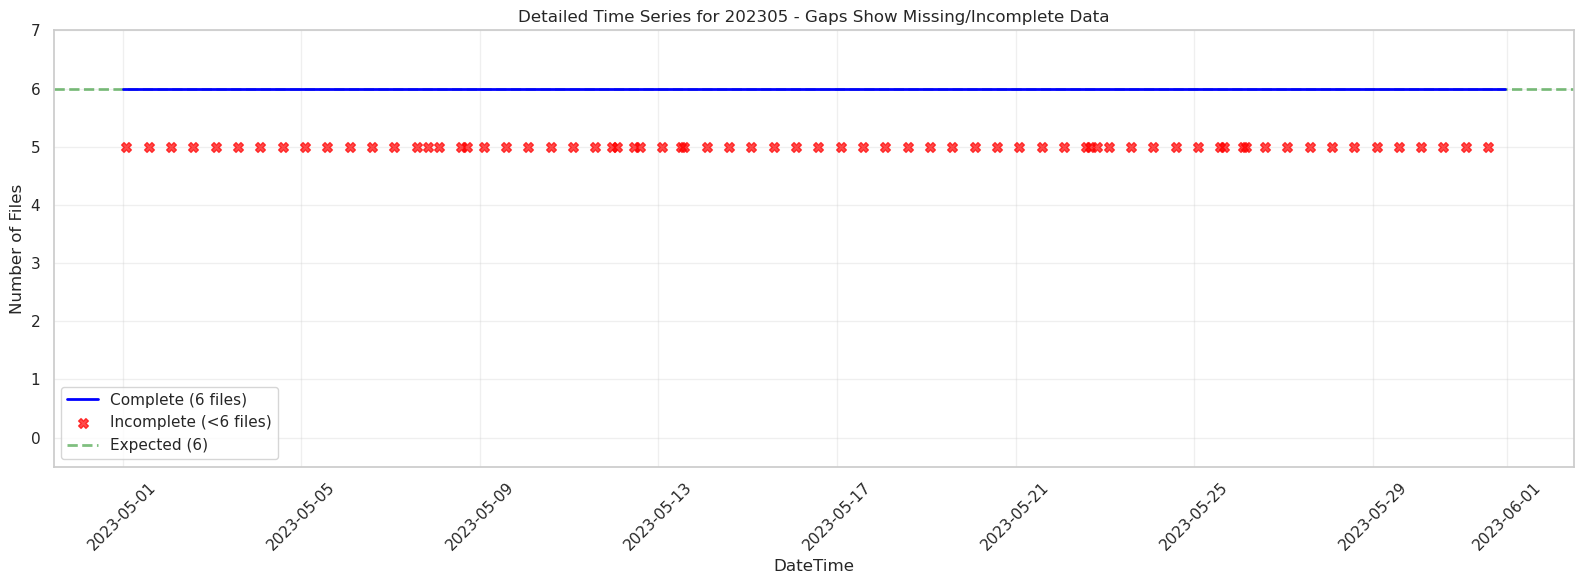

In [21]:
selected_month = '202305' # Change as needed
df_month = df_sorted[df_sorted['year_month'] == selected_month].copy()

fig, ax = plt.subplots(figsize=(16, 6))

# Plot complete hours with continuous line
df_complete = df_month[df_month['status'] == 'complete'].copy()
ax.plot(df_complete['datetime_obj'], df_complete['n_files'], 
         markersize=4, linewidth=2, color='blue', 
        label='Complete (6 files)', zorder=3)

# Plot incomplete hours as disconnected points
df_incomplete = df_month[df_month['status'] == 'incomplete'].copy()
ax.scatter(df_incomplete['datetime_obj'], df_incomplete['n_files'],
           color='red', s=50, alpha=0.7, marker='X', 
           label=f'Incomplete (<6 files)', zorder=5)

# Mark hours with 0 files
df_zero = df_month[df_month['n_files'] == 0].copy()
if len(df_zero) > 0:
    ax.scatter(df_zero['datetime_obj'], df_zero['n_files'],
               color='darkred', s=100, alpha=0.9, marker='X', 
               label='Zero files', zorder=6)

ax.axhline(6, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Expected (6)')
ax.set_xlabel('DateTime')
ax.set_ylabel('Number of Files')
ax.set_title(f'Detailed Time Series for {selected_month} - Gaps Show Missing/Incomplete Data')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## In a File

In [2]:
import rasterio
from rasterio.plot import show

In [3]:
# sample_file = dir+"202512/03/04/aod_vietnam_NC_H09_20251203_0410_L2ARP031_FLDK.02401_02401.tif"
sample_file =  "/home/slow_data/Air_Quality/AOD/202512/03/04/aod_vietnam_NC_H09_20251203_0420_L2ARP031_FLDK.02401_02401.tif"

In [4]:
with rasterio.open(sample_file) as src:
    print("="*60)
    print("TIF FILE METADATA")
    print("="*60)
    print(f"File: {sample_file}")
    print(f"Driver: {src.driver}")
    print(f"Width: {src.width} pixels")
    print(f"Height: {src.height} pixels")
    print(f"Number of bands: {src.count}")
    print(f"Data type: {src.dtypes[0]}")
    print(f"CRS (Coordinate Reference System): {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Transform:\n{src.transform}")
    print(f"Resolution: {src.res}")
    print(f"NoData value: {src.nodata}")

TIF FILE METADATA
File: /home/slow_data/Air_Quality/AOD/202512/03/04/aod_vietnam_NC_H09_20251203_0420_L2ARP031_FLDK.02401_02401.tif
Driver: GTiff
Width: 148 pixels
Height: 301 pixels
Number of bands: 6
Data type: float32
CRS (Coordinate Reference System): EPSG:4326
Bounds: BoundingBox(left=102.1, bottom=8.349999999999998, right=109.5, top=23.4)
Transform:
| 0.05, 0.00, 102.10|
| 0.00,-0.05, 23.40|
| 0.00, 0.00, 1.00|
Resolution: (0.05, 0.05)
NoData value: -9999.0


In [10]:
with rasterio.open(sample_file) as src:
    # Read first band
    data = src.read(1)
    data[data==-9999.0] = np.nan 
    
    print("\n" + "="*60)
    print("DATA ARRAY STATISTICS")
    print("="*60)
    print(f"Array shape: {data.shape}")
    print(f"Data type: {data.dtype}")
    print(f"Min value: {np.nanmin(data)}")
    print(f"Max value: {np.nanmax(data)}")
    print(f"Mean value: {np.nanmean(data)}")
    print(f"Median value: {np.nanmedian(data)}")
    print(f"Std deviation: {np.nanstd(data)}")
    print(f"Total pixels: {data.size}")
    print(f"Valid pixels: {np.sum(~np.isnan(data))}")
    print(f"NaN/NoData pixels: {np.sum(np.isnan(data))}")
    print(f"Valid data percentage: {np.sum(~np.isnan(data)) / data.size * 100:.2f}%")


DATA ARRAY STATISTICS
Array shape: (301, 148)
Data type: float32
Min value: 0.003599999938160181
Max value: 2.724799871444702
Mean value: 0.5743003487586975
Median value: 0.45809999108314514
Std deviation: 0.41992080211639404
Total pixels: 44548
Valid pixels: 540
NaN/NoData pixels: 44008
Valid data percentage: 1.21%


In [8]:
from rasterio.plot import show as rioshow
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt

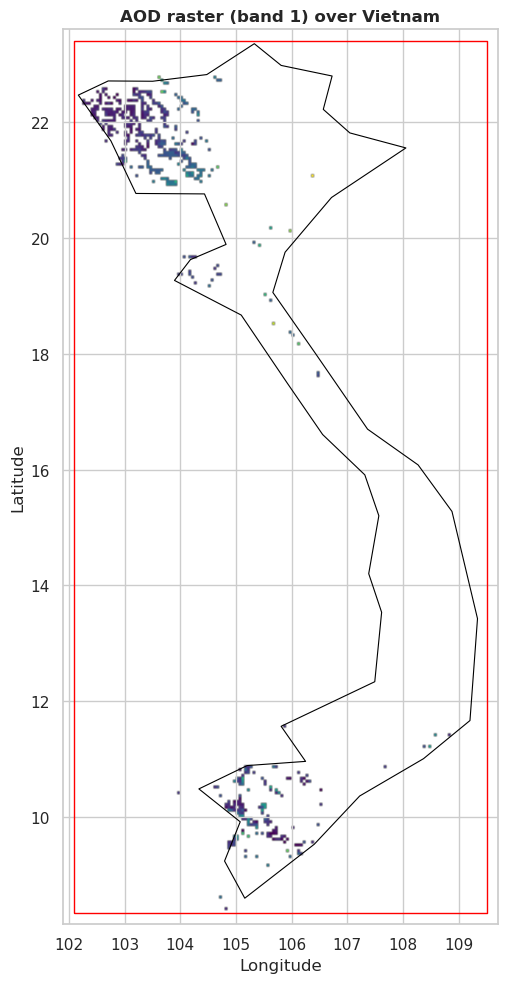

In [ ]:
with rasterio.open(sample_file) as src:
    bounds = src.bounds           # left, bottom, right, top
    crs = src.crs                 # e.g. EPSG:4326
    transform = src.transform
    width, height = src.width, src.height
    count = src.count
    dtype = src.dtypes[0]

    # Read the first band for plotting (modify if you want a different band)
    band1 = src.read(1)

# 2) Create a GeoDataFrame for the raster bounds (polygon)
raster_box = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
raster_gdf = gpd.GeoDataFrame({"geometry": [raster_box]}, crs=crs)

# 3) Load Natural Earth countries from URL
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# 4) Select Vietnam (or show whole region)
vietnam = world[world["ADMIN"] == "Vietnam"]

# 5) Plot: country base, raster as image, raster bounds polygon overlay
fig, ax = plt.subplots(figsize=(8, 10))

# Plot Vietnam (reproject if necessary)
if vietnam.crs != raster_gdf.crs:
    vietnam_plot = vietnam.to_crs(raster_gdf.crs)
else:
    vietnam_plot = vietnam

vietnam_plot.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

band1[band1==-9999.0] = np.nan 

# Plot raster using rasterio's show. We supply the extent so it falls in map coords.
# If your raster CRS is geographic (EPSG:4326) this will align with Vietnam as lon/lat.
rioshow(band1,
        transform=transform,
        ax=ax,
        title="AOD raster (band 1) over Vietnam",
        cmap="viridis",)    # you can change colormap

# Draw bounding box on top
raster_gdf.boundary.plot(ax=ax, color="red", linewidth=1)

# Optional: annotate metadata
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(bounds.left - 0.2, bounds.right + 0.2)
ax.set_ylim(bounds.bottom - 0.2, bounds.top + 0.2)

plt.tight_layout()
plt.savefig("raster_over_vietnam.png", dpi=200)
plt.show()

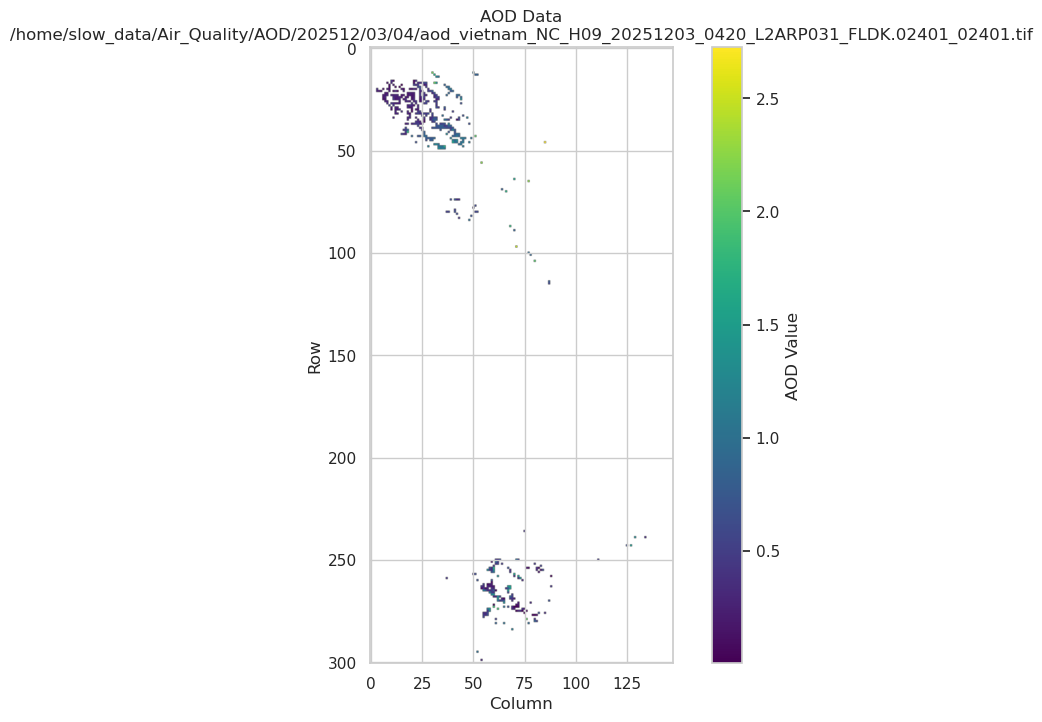

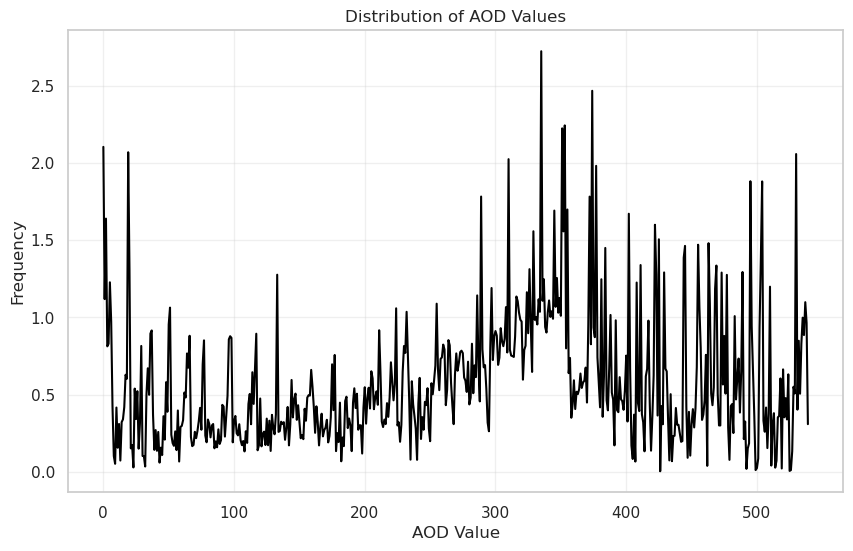

In [16]:


# Load the data once
with rasterio.open(sample_file) as src:
    data = src.read(1)
    # Replace nodata values with NaN
    data[data == -9999.0] = np.nan 

# --- Plot 1: Raw Data Map ---
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')
plt.title(f'AOD Data\n{sample_file}')
plt.xlabel('Column')
plt.ylabel('Row')
plt.colorbar(label='AOD Value')
plt.show()

# --- Plot 2: Distribution/Line Plot ---
plt.figure(figsize=(10, 6))
valid_data = data[~np.isnan(data)]
plt.plot(valid_data.flatten(), color='black')
plt.xlabel('AOD Value')
plt.ylabel('Frequency')
plt.title('Distribution of AOD Values')
plt.grid(True, alpha=0.3)
plt.show()
